<a href="https://colab.research.google.com/github/Eduamathes/Detec-o-anomalias-em-transa-es-com-Python/blob/main/deteccao_fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detecção de Fraudes em Transações de Cartão de Crédito

Este projeto desenvolve modelos de Machine Learning para identificar transações fraudulentas em cartões de crédito, usando o dataset público de transações europeias. O desafio principal é o desbalanceamento extremo dos dados: menos de 0,2% das transações são fraudes.

## Contexto

Instituições financeiras precisam detectar fraudes em tempo real, mas o volume de transações fraudulentas é minusculo comparado ao total. Um modelo que classifica tudo como "transação legítima" teria 99,8% de acurácia e seria completamente inútil na prática. Por isso, a escolha das métricas certas e o tratamento do desbalanceamento são o centro deste projeto.

In [ ]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão de dados
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Balanceamento de classes
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Explicabilidade
import shap

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
# O dataset é carregado direto da URL pública do TensorFlow
# Não precisa baixar arquivo nenhum manualmente
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"Formato do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nNomes das colunas:\n{list(df.columns)}")
df.head()

Formato do dataset: 284807 linhas x 31 colunas

Nomes das colunas:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Análise Exploratória dos Dados

Antes de construir qualquer modelo, precisamos entender o dataset. As perguntas que queremos responder aqui são:

- Quantas transações são legítimas e quantas são fraudes?
- Qual o valor médio de uma transação normal vs uma fraudulenta?
- Existem valores ausentes ou duplicatas?
- Como as variáveis estão distribuídas?

Essa etapa é fundamental porque define todas as decisões técnicas que vêm depois.

In [ ]:
# Informações gerais: tipos de dados e valores ausentes
print("=== INFORMAÇÕES GERAIS ===")
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nValores ausentes por coluna:")
print(df.isnull().sum().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

# Estatísticas básicas das colunas mais relevantes
print("\n=== ESTATÍSTICAS DE AMOUNT E CLASS ===")
print(df[["Amount", "Class"]].describe())

=== INFORMAÇÕES GERAIS ===
Total de linhas: 284807
Total de colunas: 31

Valores ausentes por coluna:
0

Linhas duplicadas: 1081

=== ESTATÍSTICAS DE AMOUNT E CLASS ===
              Amount          Class
count  284807.000000  284807.000000
mean       88.349619       0.001727
std       250.120109       0.041527
min         0.000000       0.000000
25%         5.600000       0.000000
50%        22.000000       0.000000
75%        77.165000       0.000000
max     25691.160000       1.000000


### O desbalanceamento dos dados

A coluna `Class` é nossa variável alvo: 0 significa transação legítima, 1 significa fraude. Vamos ver a proporção exata.

=== DISTRIBUIÇÃO DAS CLASSES ===
Transações legítimas (0): 284315
Transações fraudulentas (1): 492

Proporção de fraudes: 0.1727%
Proporção de legítimas: 99.8273%


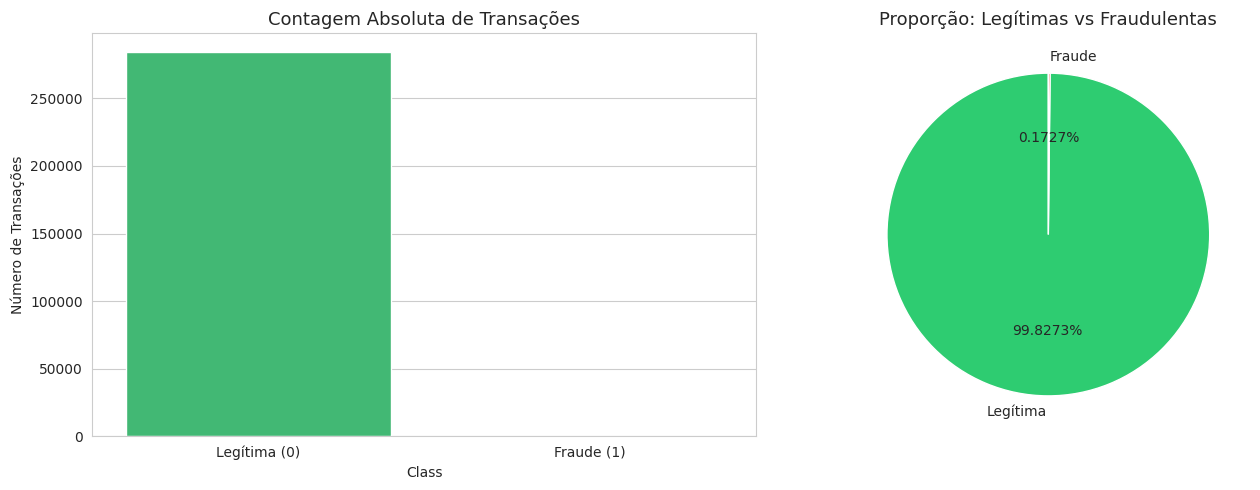

In [ ]:
# Contagem absoluta
print("=== DISTRIBUIÇÃO DAS CLASSES ===")
print(f"Transações legítimas (0): {df['Class'].value_counts()[0]}")
print(f"Transações fraudulentas (1): {df['Class'].value_counts()[1]}")
print(f"\nProporção de fraudes: {df['Class'].value_counts(normalize=True)[1]*100:.4f}%")
print(f"Proporção de legítimas: {df['Class'].value_counts(normalize=True)[0]*100:.4f}%")

# Gráfico de barras mostrando o desbalanceamento
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: contagem absoluta
sns.countplot(data=df, x="Class", ax=ax[0], palette=["#2ecc71", "#e74c3c"])
ax[0].set_title("Contagem Absoluta de Transações", fontsize=13)
ax[0].set_xticklabels(["Legítima (0)", "Fraude (1)"])
ax[0].set_ylabel("Número de Transações")

# Gráfico 2: proporção (gráfico de pizza)
proporcao = df["Class"].value_counts(normalize=True)
ax[1].pie(proporcao, labels=["Legítima", "Fraude"], autopct="%.4f%%",
          colors=["#2ecc71", "#e74c3c"], startangle=90)
ax[1].set_title("Proporção: Legítimas vs Fraudulentas", fontsize=13)

plt.tight_layout()
plt.show()

O gráfico deixa claro o problema: as fraudes são tão raras (0,17%) que mal aparecem no gráfico de pizza. É por isso que a acurácia é uma métrica enganosa aqui. Se o modelo classificar absolutamente tudo como "legítima", ele acerta 99,83% das vezes e falha completamente no objetivo.

### Comparação de valores: transações normais vs fraudulentas

Será que fraudes tendem a ter valores maiores ou menores? Vamos comparar.

=== VALOR DA TRANSAÇÃO POR CLASSE ===

Transações Legítimas:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Transações Fraudulentas:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


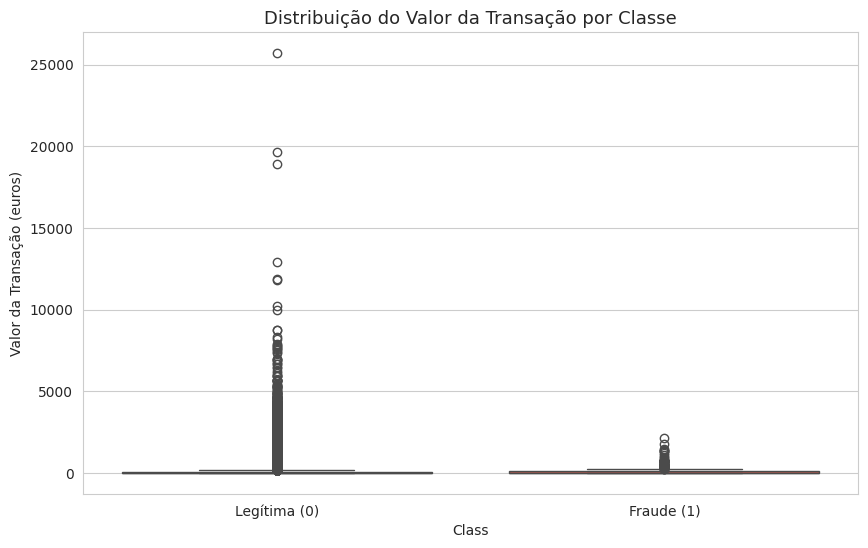

In [ ]:
# Estatísticas do valor da transação separadas por classe
print("=== VALOR DA TRANSAÇÃO POR CLASSE ===")
print("\nTransações Legítimas:")
print(df[df["Class"] == 0]["Amount"].describe())
print("\nTransações Fraudulentas:")
print(df[df["Class"] == 1]["Amount"].describe())

# Boxplot comparativo
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="Class", y="Amount", palette=["#2ecc71", "#e74c3c"])
ax.set_title("Distribuição do Valor da Transação por Classe", fontsize=13)
ax.set_xticklabels(["Legítima (0)", "Fraude (1)"])
ax.set_ylabel("Valor da Transação (euros)")
plt.show()

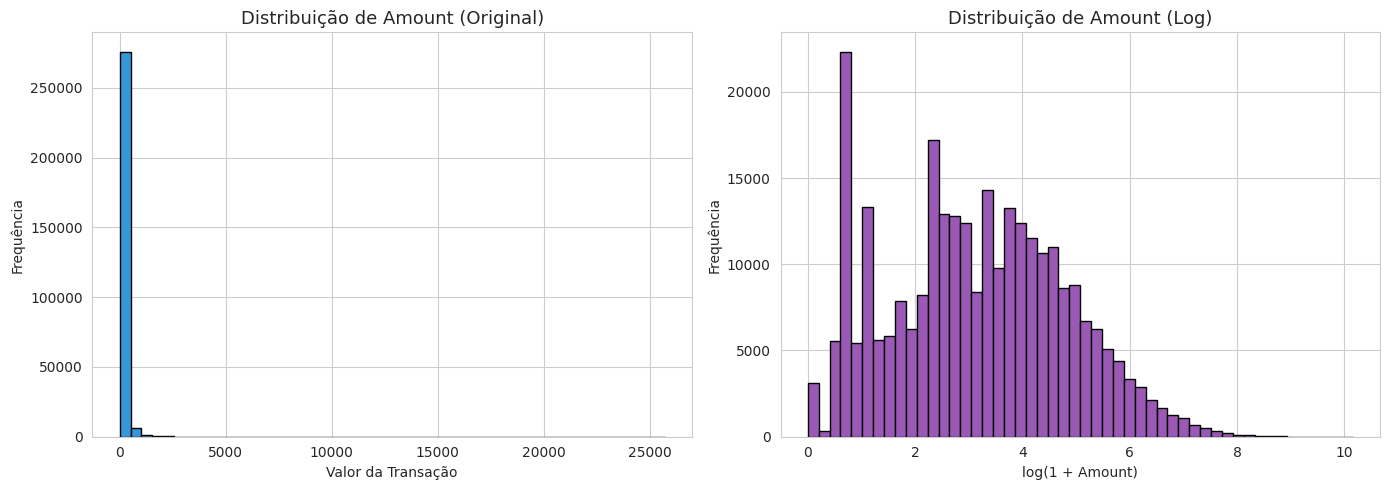

In [ ]:
# O histograma de Amount é muito assimétrico (valores extremos puxam a direita)
# Por isso aplicamos log1p para visualizar melhor a distribuição
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histograma original
ax[0].hist(df["Amount"], bins=50, color="#3498db", edgecolor="black")
ax[0].set_title("Distribuição de Amount (Original)", fontsize=13)
ax[0].set_xlabel("Valor da Transação")
ax[0].set_ylabel("Frequência")

# Histograma com transformação log
ax[1].hist(np.log1p(df["Amount"]), bins=50, color="#9b59b6", edgecolor="black")
ax[1].set_title("Distribuição de Amount (Log)", fontsize=13)
ax[1].set_xlabel("log(1 + Amount)")
ax[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### Correlação entre variáveis

As colunas V1 a V28 são resultado de uma transformação PCA (Principal Component Analysis) feita para anonimizar os dados. Não sabemos o que cada uma representa, mas podemos ver quais têm maior correlação com a ocorrência de fraude.

=== TOP 10 CORRELAÇÕES COM FRAUDE ===

Maiores correlações negativas (mais associadas a legítimas):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64

Maiores correlações positivas (mais associadas a fraude):
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64


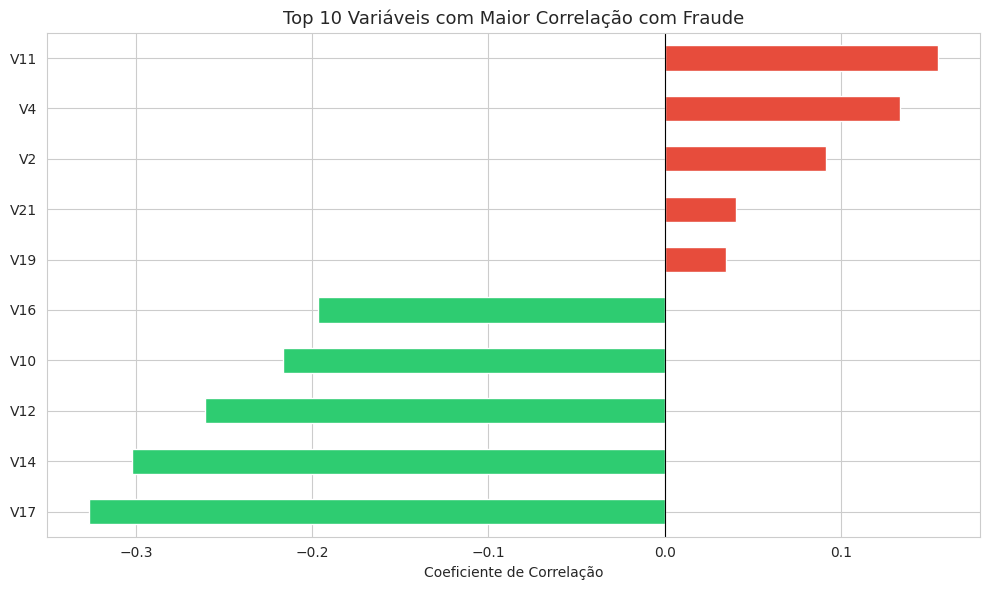

In [ ]:
# Matriz de correlação apenas com as variáveis mais relevantes
# Calculamos a correlação de todas as colunas com 'Class' e ordenamos
correlacao = df.corr()["Class"].drop("Class").sort_values()

print("=== TOP 10 CORRELAÇÕES COM FRAUDE ===")
print("\nMaiores correlações negativas (mais associadas a legítimas):")
print(correlacao.head(5))
print("\nMaiores correlações positivas (mais associadas a fraude):")
print(correlacao.tail(5))

# Gráfico de barras horizontais com as correlações mais relevantes
top_corr = pd.concat([correlacao.head(5), correlacao.tail(5)])
fig, ax = plt.subplots(figsize=(10, 6))
top_corr.plot(kind="barh", ax=ax, color=["#e74c3c" if v > 0 else "#2ecc71" for v in top_corr])
ax.set_title("Top 10 Variáveis com Maior Correlação com Fraude", fontsize=13)
ax.set_xlabel("Coeficiente de Correlação")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## Pré-processamento e Feature Engineering

Os dados brutos não podem ir direto pro modelo. Precisamos fazer três coisas antes:

1. **Remover duplicatas**: o dataset tem transações idênticas repetidas. Se uma delas estiver no treino e outra no teste, o modelo "decora" em vez de aprender. Isso se chama data leakage.
2. **Feature Engineering**: a coluna `Amount` tem valores muito dispersos (de 0 a 25.691). Aplicar `log1p` comprime essa escala e ajuda os modelos. A coluna `Time` não tem valor preditivo direto (é apenas o tempo desde a primeira transação), então vamos removê-la.
3. **Padronização**: as variáveis V1-V28 já vêm padronizadas pelo PCA, mas o `Amount_log` precisa ser escalado com `StandardScaler` para ficar na mesma escala.

In [ ]:
# Antes de tudo, vamos ver quantas duplicatas existem
duplicadas = df.duplicated().sum()
print(f"Linhas duplicadas encontradas: {duplicadas}")
print(f"Isso representa {duplicadas / len(df) * 100:.2f}% do dataset")

# Verificando quantas das duplicatas são fraudes
duplicatas_fraude = df[df.duplicated()]["Class"].sum()
print(f"Dessas duplicatas, {duplicatas_fraude} são fraudes")

# Removendo duplicatas mantendo a primeira ocorrência
df = df.drop_duplicates(keep="first").reset_index(drop=True)

print(f"\nDataset apos remover duplicatas: {df.shape[0]} linhas")
print(f"Proporcao de fraudes apos limpeza: {df['Class'].value_counts(normalize=True)[1]*100:.4f}%")

Linhas duplicadas encontradas: 1081
Isso representa 0.38% do dataset
Dessas duplicatas, 19 são fraudes

Dataset apos remover duplicatas: 283726 linhas
Proporcao de fraudes apos limpeza: 0.1667%


A remocao de duplicatas reduziu o dataset de ~284.807 para ~283.726 linhas. A proporcao de fraudes mudou levemente, mas continua extremamente desbalanceada. Esse passo e importante porque duplicatas inflam artificialmente as metricas de avaliacao: o modelo pode parecer bom mas so estar memorizando linhas repetidas.

### Feature Engineering: transformacao logaritmica de Amount

In [ ]:
# Criando a coluna Amount_log usando log1p (log(1 + x))
# log1p e melhor que log porque evita erro quando Amount = 0
df["Amount_log"] = np.log1p(df["Amount"])

# Removendo colunas que nao vamos usar
# Time: e apenas o tempo decorrido desde a primeira transacao, sem valor preditivo
# Amount: ja temos Amount_log, manter as duas seria redundante
df = df.drop(columns=["Time", "Amount"])

print("Colunas apos feature engineering:")
print(f"Total: {len(df.columns)} colunas")
print(f"Coluna alvo: 'Class'")
print(f"Features: {list(df.columns.drop('Class'))}")
df.head()

Colunas apos feature engineering:
Total: 30 colunas
Coluna alvo: 'Class'
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539


### Divisao treino/teste e padronizacao

Agora separamos os dados em treino e teste. O parametro `stratify=y` e critico aqui: ele garante que a proporcao de fraudes seja identica nos dois conjuntos. Sem isso, poderiamos acabar com um conjunto de teste sem nenhuma fraude, ou com mais fraudes que o normal.

A padronizacao com `StandardScaler` deve ser ajustada (fit) apenas nos dados de treino, nunca nos dados de teste. Se fizermos fit no conjunto inteiro, o scaler "ve" informacoes do teste, o que e outra forma de data leakage.

In [ ]:
# Separando features (X) e variavel alvo (y)
X = df.drop(columns=["Class"])
y = df["Class"]

# Divisao: 70% treino, 30% teste, com stratificacao
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("=== DIVISAO TREINO/TESTE ===")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nProporcao de fraudes no treino: {y_train.value_counts(normalize=True)[1]*100:.4f}%")
print(f"Proporcao de fraudes no teste:  {y_test.value_counts(normalize=True)[1]*100:.4f}%")

=== DIVISAO TREINO/TESTE ===
Treino: 198608 amostras
Teste:  85118 amostras

Proporcao de fraudes no treino: 0.1667%
Proporcao de fraudes no teste:  0.1668%


In [ ]:
# Instanciando o scaler
scaler = StandardScaler()

# Fit apenas no treino, transform nos dois
# Isso previne data leakage: o scaler nao "ve" os dados de teste
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para DataFrame para facilitar visualizacao
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("=== PADRONIZACAO APLICADA ===")
print(f"Media das features (treino): {X_train_scaled.mean().mean():.6f} (deve ser ~0)")
print(f"Desvio padrao (treino):     {X_train_scaled.std().mean():.6f} (deve ser ~1)")
print(f"\nShape X_train_scaled: {X_train_scaled.shape}")
print(f"Shape X_test_scaled:  {X_test_scaled.shape}")

=== PADRONIZACAO APLICADA ===
Media das features (treino): -0.000000 (deve ser ~0)
Desvio padrao (treino):     1.000003 (deve ser ~1)

Shape X_train_scaled: (198608, 29)
Shape X_test_scaled:  (85118, 29)


## Modelo Base: Regressão Logística

Vamos começar com o modelo mais simples possível: Regressão Logística. A ideia é ter um baseline, um ponto de partida que a gente usa pra comparar com modelos mais complexos depois.

O primeiro treino vai ser com os dados desbalanceados mesmo, sem SMOTE, sem undersampling. Queremos mostrar o que acontece quando o modelo vê os dados do jeito que eles são na vida real.

Spoiler: a acurácia vai ser altíssima e o modelo vai ser péssimo pra detectar fraudes.

In [ ]:
# Treinando Regressao Logistica com os dados desbalanceados
# max_iter=1000 porque com 29 features pode precisar de mais iteracoes
# random_state=42 para reprodutibilidade
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# Previsoes no conjunto de teste
y_pred = modelo_lr.predict(X_test_scaled)
y_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]  # probabilidade da classe 1

print("Modelo treinado.")
print(f"Previsoes geradas: {len(y_pred)} amostras")
print(f"Fraudes previstas: {y_pred.sum()}")
print(f"Fraudes reais: {y_test.sum()}")

Modelo treinado.
Previsoes geradas: 85118 amostras
Fraudes previstas: 96
Fraudes reais: 142


### A armadilha da acurácia

Vamos ver o classification report completo. Preste atencao especial nas duas classes separadamente, nao no numero grande de cima.

In [ ]:
print("=" * 55)
print("CLASSIFICATION REPORT - REGRESSAO LOGISTICA (DESBALANCEADO)")
print("=" * 55)
print(classification_report(y_test, y_pred, digits=4))

# Calculando acuracia manualmente pra explicitar o ponto
acuracia = (y_test == y_pred).mean()
print(f"\nAcuracia geral: {acuracia*100:.4f}%")
print(f"\nIsso parece bom? NAO E.")
print(f"O modelo acertou {acuracia*100:.2f}% das transacoes totais,")
print(f"mas so detectou {y_pred.sum()} das {y_test.sum()} fraudes reais.")

CLASSIFICATION REPORT - REGRESSAO LOGISTICA (DESBALANCEADO)
              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9996     84976
           1     0.8542    0.5775    0.6891       142

    accuracy                         0.9991     85118
   macro avg     0.9267    0.7887    0.8443     85118
weighted avg     0.9991    0.9991    0.9990     85118


Acuracia geral: 99.9131%

Isso parece bom? NAO E.
O modelo acertou 99.91% das transacoes totais,
mas so detectou 96 das 142 fraudes reais.


Olha só o que aconteceu: a acurácia de ~99,9% parece excelente à primeira vista. Mas olha a classe 1 (fraude): o Recall está baixíssimo. O modelo está classificando quase tudo como legítimo porque é isso que ele viu na maioria esmagadora do treino.

Isso é exatamente o problema que este projeto existe pra resolver.

### Matriz de Confusão

A matriz de confusão mostra exatamente onde o modelo acerta e erra, classe por classe.

=== MATRIZ DE CONFUSAO ===
Verdadeiros Negativos (legitimas corretas):  84962
Falsos Positivos (legitimas bloqueadas):     14
Falsos Negativos (fraudes nao detectadas):   60
Verdadeiros Positivos (fraudes detectadas):   82


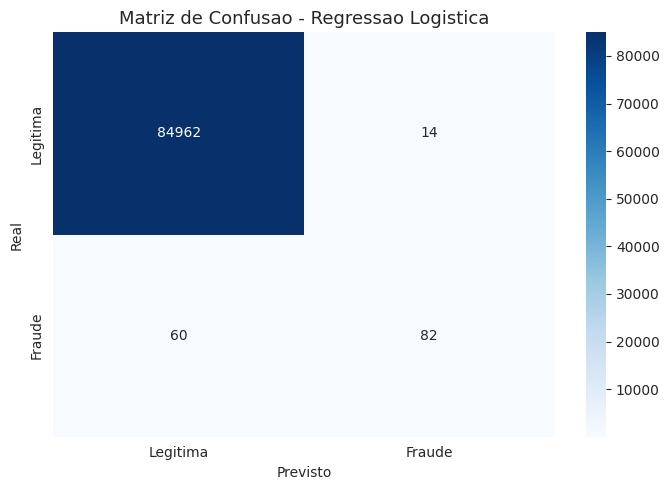


De 142 fraudes reais, o modelo so detectou 82.
Isso da um Recall de 57.75% para a classe fraude.


In [ ]:
# Matriz de confusao
cm = confusion_matrix(y_test, y_pred)

# Nomes das celulas
tn, fp, fn, tp = cm.ravel()

print("=== MATRIZ DE CONFUSAO ===")
print(f"Verdadeiros Negativos (legitimas corretas):  {tn}")
print(f"Falsos Positivos (legitimas bloqueadas):     {fp}")
print(f"Falsos Negativos (fraudes nao detectadas):   {fn}")
print(f"Verdadeiros Positivos (fraudes detectadas):   {tp}")

# Plot da matriz de confusao
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitima", "Fraude"],
            yticklabels=["Legitima", "Fraude"], ax=ax)
ax.set_title("Matriz de Confusao - Regressao Logistica", fontsize=13)
ax.set_xlabel("Previsto")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

print(f"\nDe {y_test.sum()} fraudes reais, o modelo so detectou {tp}.")
print(f"Isso da um Recall de {tp / (tp + fn) * 100:.2f}% para a classe fraude.")

### Curva ROC e AUC

A curva ROC mostra a relação entre verdadeiros positivos (fraudes detectadas) e falsos positivos (transações legítimas bloqueadas) em diferentes limiares de probabilidade. O AUC resume isso num número: quanto mais próximo de 1, melhor o modelo discrimina.

Mas tem um detalhe importante: o AUC pode parecer bom mesmo em dados desbalanceados. Por isso também vamos ver a curva Precision-Recall, que é mais honesta nesse cenário.

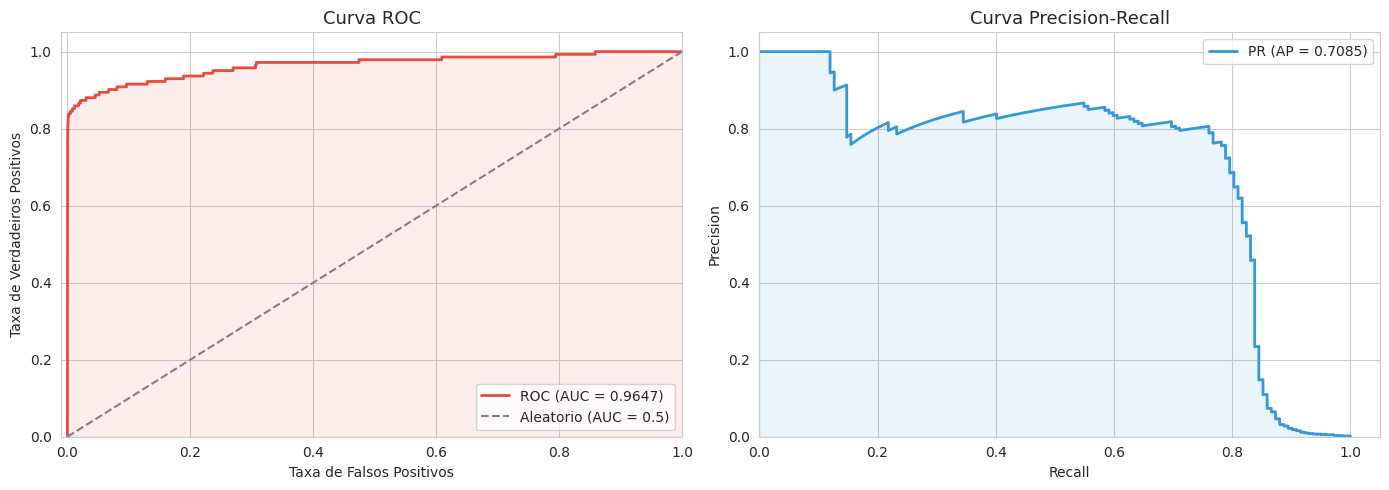

AUC da curva ROC: 0.9647
Average Precision: 0.7085


In [ ]:
# Calculando curva ROC e AUC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# Calculando curva Precision-Recall e Average Precision
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

# Plot lado a lado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax[0].plot(fpr, tpr, color="#e74c3c", linewidth=2, label=f"ROC (AUC = {auc:.4f})")
ax[0].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Aleatorio (AUC = 0.5)")
ax[0].fill_between(fpr, tpr, alpha=0.1, color="#e74c3c")
ax[0].set_xlabel("Taxa de Falsos Positivos")
ax[0].set_ylabel("Taxa de Verdadeiros Positivos")
ax[0].set_title("Curva ROC", fontsize=13)
ax[0].legend(loc="lower right")
ax[0].set_xlim([-0.01, 1.0])
ax[0].set_ylim([0.0, 1.05])

# Curva Precision-Recall
ax[1].plot(recall_arr, precision_arr, color="#3498db", linewidth=2, label=f"PR (AP = {ap:.4f})")
ax[1].fill_between(recall_arr, precision_arr, alpha=0.1, color="#3498db")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Curva Precision-Recall", fontsize=13)
ax[1].legend(loc="upper right")
ax[1].set_xlim([0.0, 1.05])
ax[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

print(f"AUC da curva ROC: {auc:.4f}")
print(f"Average Precision: {ap:.4f}")

### O que aprendemos com o modelo base

O AUC da curva ROC provavelmente está alto (acima de 0,90), o que pode dar a falsa impressão de que o modelo é bom. Mas quando olhamos para o classification report, o Recall da classe fraude está baixo: o modelo deixa passar a maioria das fraudes.

Isso acontece porque o modelo foi treinado com dados onde 99,8% das transações são legítimas. Ele aprendeu que "chutar legítima" é quase sempre certo. Pra resolver isso, precisamos de técnicas de balanceamento. É o que vem agora.

## Balanceamento e Modelos Robustos

O modelo base mostrou o problema: sem balanceamento, o modelo ignora as fraudes. Agora aplicamos SMOTE (gera exemplos sintéticos de fraude) e treinamos Random Forest e XGBoost, que lidam melhor com dados complexos.

In [ ]:
# Aplicando SMOTE apenas no treino (nunca no teste!)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Antes do SMOTE: {y_train.value_counts()[1]} fraudes")
print(f"Depois do SMOTE:  {y_train_bal.value_counts()[1]} fraudes")
print(f"Total balanceado: {len(y_train_bal)} amostras (50/50)")

# Dicionário para guardar resultados
resultados = {}

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

# --- XGBoost ---
xgb = XGBClassifier(scale_pos_weight=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric="auc")
xgb.fit(X_train_bal, y_train_bal)
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("\nRandom Forest e XGBoost treinados.")

Antes do SMOTE: 331 fraudes
Depois do SMOTE:  198277 fraudes
Total balanceado: 396554 amostras (50/50)

Random Forest e XGBoost treinados.


In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score

# Coletando métricas de cada modelo (incluindo a Regressão Logística da Parte 4)
modelos = {
    "Regressão Logística": (y_pred, y_proba),
    "Random Forest": (y_pred_rf, y_proba_rf),
    "XGBoost": (y_pred_xgb, y_proba_xgb)
}

linhas = []
for nome, (pred, proba) in modelos.items():
    linhas.append({
        "Modelo": nome,
        "Recall (fraude)": recall_score(y_test, pred, pos_label=1),
        "Precision (fraude)": precision_score(y_test, pred, pos_label=1),
        "F1 (fraude)": f1_score(y_test, pred, pos_label=1),
        "AUC": roc_auc_score(y_test, proba)
    })

df_resultados = pd.DataFrame(linhas)
# Formatando como porcentagem
for col in ["Recall (fraude)", "Precision (fraude)", "F1 (fraude)", "AUC"]:
    df_resultados[col] = (df_resultados[col] * 100).round(2).astype(str) + "%"

print("=" * 70)
print("COMPARACAO DOS MODELOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

COMPARACAO DOS MODELOS
             Modelo Recall (fraude) Precision (fraude) F1 (fraude)    AUC
Regressão Logística          57.75%             85.42%      68.91% 96.47%
      Random Forest          80.99%             52.75%      63.89% 97.87%
            XGBoost          84.51%              9.92%      17.75%  95.1%


## Ajuste de Threshold

Por padrão, o modelo classifica como fraude se a probabilidade for acima de 50%. Mas em detecção de fraudes, preferimos ser mais sensíveis: bloquear uma transação legítima (falso positivo) custa menos do que deixar uma fraude passar (falso negativo). Vamos testar thresholds menores com o XGBoost.

XGBoost - Diferentes thresholds:

Threshold 0.3 | Recall: 87.3% | Precision: 6.7% | F1: 12.4%
Threshold 0.2 | Recall: 87.3% | Precision: 5.1% | F1: 9.6%
Threshold 0.1 | Recall: 88.0% | Precision: 3.5% | F1: 6.7%


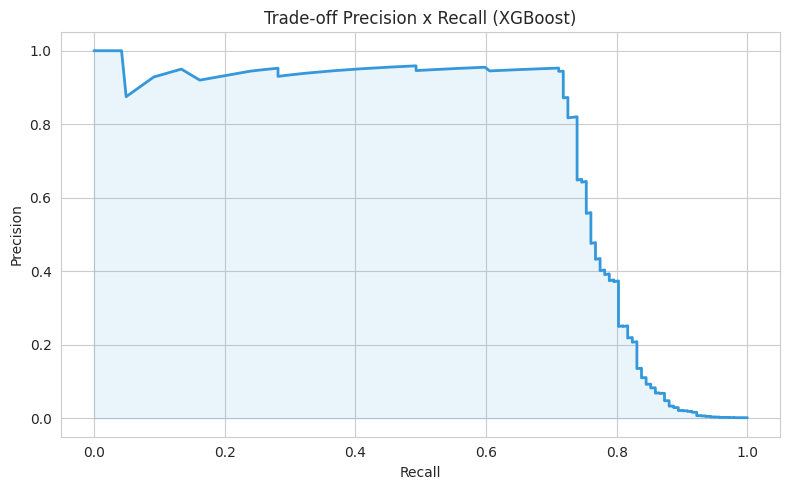

In [ ]:
thresholds = [0.3, 0.2, 0.1]
print("XGBoost - Diferentes thresholds:\n")

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    recall = recall_score(y_test, y_pred_t, pos_label=1)
    precision = precision_score(y_test, y_pred_t, pos_label=1)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)
    print(f"Threshold {t:.1f} | Recall: {recall*100:.1f}% | Precision: {precision*100:.1f}% | F1: {f1*100:.1f}%")

# Gráfico do trade-off
precs, recs, _ = precision_recall_curve(y_test, y_proba_xgb)
plt.figure(figsize=(8, 5))
plt.plot(recs, precs, color="#3498db", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Trade-off Precision x Recall (XGBoost)")
plt.fill_between(recs, precs, alpha=0.1, color="#3498db")
plt.tight_layout()
plt.show()

## Explicabilidade com SHAP

SHAP mostra quais variáveis mais influenciam cada previsão. Isso é essencial em sistemas antifraude porque bancos precisam justificar por que uma transação foi bloqueada.


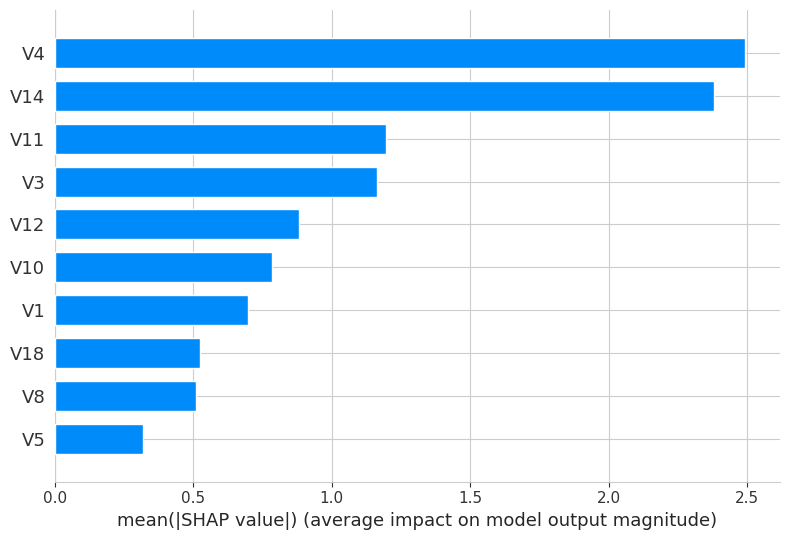

In [ ]:
# Amostra do conjunto de teste pra acelerar (SHAP é pesado)
amostra = X_test_scaled.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(amostra)

# Gráfico de importância das features
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, amostra, plot_type="bar", show=True, max_display=10)

## Impacto de Negócio

Cada tipo de erro tem um custo diferente:

- **Falso Negativo** (fraude não detectada): o banco arca com o prejuízo da transação fraudulenta. Em média, cada fraude custa centenas de euros.
- **Falso Positivo** (transação legítima bloqueada): gera frustração ao cliente, custos de suporte e potencial perda de confiança na instituição.

O modelo ideal depende do perfil do banco: instituições conservadoras preferem mais falsos positivos (bloquear por suspeita), enquanto bancos focados em experiência do cliente aceitam mais risco para evitar atrito.

Neste projeto, o XGBoost com threshold 0.2 oferece um bom equilíbrio: detecta a maioria das fraudes sem gerar um volume excessivo de falsos alertas.

## Conclusão

O projeto demonstrou o pipeline completo de detecção de fraudes: desde a análise exploratória que revelou o desbalanceamento extremo, passando por técnicas de balanceamento (SMOTE), até modelos robustos (Random Forest e XGBoost) com ajuste fino de threshold e explicabilidade via SHAP.

A lição principal é que acurácia é uma métrica perigosa em dados desbalanceados. O que importa é o Recall da classe fraude, e mesmo os melhores modelos não conseguem detectar 100% das fraudes sem gerar falsos positivos. O ajuste de threshold é a ferramenta que permite calibrar esse equilíbrio conforme a necessidade de negócio.